# MFA Tutorial on a Mixture-of-Experts (MoE) Model

This notebook mirrors the original MFA tutorial through **visualization**, while also tracking **which MoE expert was activated per token**.

## What this notebook covers

1. Load a Hugging Face MoE Causal LM
2. Extract hidden-state activations + router logits
3. Build MFA training loaders
4. Initialize and train MFA
5. Interpret components with top tokens
6. Visualize local subspaces
7. Track expert usage overall and per MFA component

In [1]:
from __future__ import annotations
import os
import random
from collections import Counter

import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.utils.data import DataLoader, TensorDataset

from data_utils.concept_dataset import SupervisedConceptDataset
from initializations.projected_knn import ReservoirKMeans
from modeling.mfa import MFA
from modeling.train import train_nll
from analysis.subspace_interpretation import get_top_strings_per_concept
import analysis.subspace_visualization as sv

c:\Users\Leonardo\Repos\decomposing-activations-local-geometry\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Paths and runtime
data_path = "./data/supervised.json"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# MoE model (change to any router-based MoE CausalLM available to you)
model_name = "allenai/OLMoE-1B-7B-0924"

# Reasonable extraction caps for interactive runs
batch_size_extract = 1
max_points = None
max_batches = 1000
max_length = 96
activation_layer = 8
router_layer = 8
sample_seed = 0
shuffle_batches = True
val_frac = 0.1

num_centroids = 80
rank = 8
epochs = 2
lr = 1.5e-3

Using device: cuda


In [3]:
# Load tokenizer/model
dtype = torch.float16 if device == "cuda" else torch.float32
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model_hf = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=dtype,
    trust_remote_code=True,
)
model_hf = model_hf.to(device)
model_hf.eval()
print("Model loaded:", model_name)

Loading checkpoint shards: 100%|██████████| 3/3 [00:13<00:00,  4.53s/it]


Model loaded: allenai/OLMoE-1B-7B-0924


In [4]:
dataset_obj = SupervisedConceptDataset(data_path)
print("Dataset loaded from", data_path)

Dataset loaded from ./data/supervised.json


In [5]:
# Probe router availability and shapes on one batch
probe_batch = dataset_obj.get_batches(batch_size=1)[0]
probe_enc = tokenizer(
    probe_batch["prompt"],
    return_tensors="pt",
    padding=True,
    truncation=True,
)
probe_enc = {k: v.to(model_hf.device) for k, v in probe_enc.items()}

with torch.no_grad():
    probe_out = model_hf(
        **probe_enc,
        output_hidden_states=True,
        output_router_logits=True,
        use_cache=False,
    )

if (not hasattr(probe_out, "router_logits")) or (probe_out.router_logits is None):
    raise RuntimeError("This model did not return router logits. Pick a router-based MoE model.")

router_list = list(probe_out.router_logits)
print("#hidden_states:", len(probe_out.hidden_states), "(includes embedding state)")
print("#router tensors:", len(router_list))
print("raw router tensor shapes:", [tuple(t.shape) for t in router_list[:min(5, len(router_list))]])

del probe_out

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


#hidden_states: 17 (includes embedding state)
#router tensors: 16
raw router tensor shapes: [(31, 64), (31, 64), (31, 64), (31, 64), (31, 64)]


In [6]:
# Inspect likely router/gate modules in the already-loaded model
router_like = [n for n, _m in model_hf.named_modules() if ("gate" in n.lower() or "router" in n.lower())]
print("Found router/gate-like modules:", len(router_like))
for n in router_like[:80]:
    print(n)

Found router/gate-like modules: 1040
model.layers.0.mlp.gate
model.layers.0.mlp.experts.0.gate_proj
model.layers.0.mlp.experts.1.gate_proj
model.layers.0.mlp.experts.2.gate_proj
model.layers.0.mlp.experts.3.gate_proj
model.layers.0.mlp.experts.4.gate_proj
model.layers.0.mlp.experts.5.gate_proj
model.layers.0.mlp.experts.6.gate_proj
model.layers.0.mlp.experts.7.gate_proj
model.layers.0.mlp.experts.8.gate_proj
model.layers.0.mlp.experts.9.gate_proj
model.layers.0.mlp.experts.10.gate_proj
model.layers.0.mlp.experts.11.gate_proj
model.layers.0.mlp.experts.12.gate_proj
model.layers.0.mlp.experts.13.gate_proj
model.layers.0.mlp.experts.14.gate_proj
model.layers.0.mlp.experts.15.gate_proj
model.layers.0.mlp.experts.16.gate_proj
model.layers.0.mlp.experts.17.gate_proj
model.layers.0.mlp.experts.18.gate_proj
model.layers.0.mlp.experts.19.gate_proj
model.layers.0.mlp.experts.20.gate_proj
model.layers.0.mlp.experts.21.gate_proj
model.layers.0.mlp.experts.22.gate_proj
model.layers.0.mlp.experts.23

## Extract activations and active experts

For each non-padding token:
- store activation at `activation_layer`
- store top expert index from `router_layer`
- store top expert probability

In [7]:
@torch.no_grad()
def extract_moe_activations_and_experts(
    dataset_obj,
    model,
    tokenizer,
    activation_layer: int,
    router_layer: int,
    batch_size: int = 4,
    max_points: int | None = None,
    max_batches: int | None = None,
    max_length: int = 64,
    shuffle_batches: bool = True,
    seed: int = 0,
 ):
    acts_all = []
    toks_all = []
    expert_all = []
    expert_p_all = []

    kept = 0
    bos_id = tokenizer.bos_token_id

    batches = list(dataset_obj.get_batches(batch_size=batch_size))
    if shuffle_batches:
        rng = random.Random(seed)
        rng.shuffle(batches)

    total_batches = len(batches) if max_batches is None else min(len(batches), max_batches)
    pbar = tqdm(enumerate(batches), total=total_batches, desc="Extracting activations", unit="batch")

    for batch_idx, batch in pbar:
        if max_batches is not None and batch_idx >= max_batches:
            break

        prompts = batch["prompt"]
        enc = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
)
        enc = {k: v.to(model.device) for k, v in enc.items()}

        out = model(
            **enc,
            output_hidden_states=True,
            output_router_logits=True,
            use_cache=False,
        )

        hidden_states = out.hidden_states
        router_logits = out.router_logits
        if router_logits is None:
            raise RuntimeError("Router logits are None.")

        router_list = list(router_logits)
        if activation_layer >= len(hidden_states):
            raise ValueError(f"activation_layer={activation_layer} out of range [0, {len(hidden_states)-1}]")
        if router_layer >= len(router_list):
            raise ValueError(f"router_layer={router_layer} out of range [0, {len(router_list)-1}]")

        h = hidden_states[activation_layer]  # (B,S,D)
        r = router_list[router_layer]        # model-dependent shape

        if r.dim() == 4:
            r = r.mean(dim=-2)

        input_ids = enc["input_ids"]
        B, S = input_ids.shape

        # Normalize router logits to (B,S,E)
        if r.dim() == 3 and r.shape[0] == B and r.shape[1] == S:
            r3 = r
        elif r.dim() == 2 and r.shape[0] == B * S:
            r3 = r.view(B, S, -1)
        elif r.dim() == 2 and B == 1 and r.shape[0] == S:
            r3 = r.unsqueeze(0)
        else:
            raise ValueError(
                f"Unexpected router logits shape {tuple(r.shape)} for input shape {(B, S)}. "
                "Try a different router_layer after checking the probe output."
            )

        probs = torch.softmax(r3.float(), dim=-1)
        top_p, top_expert = probs.max(dim=-1)

        mask = enc["attention_mask"].bool()
        if bos_id is not None:
            mask = mask & (input_ids != bos_id)

        acts = h[mask].detach().cpu()
        toks = input_ids[mask].detach().cpu()
        exp = top_expert[mask].detach().cpu()
        exp_p = top_p[mask].detach().cpu()

        acts_all.append(acts)
        toks_all.append(toks)
        expert_all.append(exp)
        expert_p_all.append(exp_p)

        kept += acts.size(0)
        if (batch_idx + 1) % 25 == 0:
            pbar.set_postfix(tokens=kept)

        if max_points is not None and kept >= max_points:
            pbar.set_postfix(tokens=kept, stopped="max_points")
            break

        del out
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    X = torch.cat(acts_all, dim=0)
    T = torch.cat(toks_all, dim=0)
    E = torch.cat(expert_all, dim=0)
    P = torch.cat(expert_p_all, dim=0)

    if max_points is not None and X.size(0) > max_points:
        X = X[:max_points]
        T = T[:max_points]
        E = E[:max_points]
        P = P[:max_points]

    return X, T, E, P

In [8]:
X_all, tokens, expert_ids, expert_probs = extract_moe_activations_and_experts(
    dataset_obj=dataset_obj,
    model=model_hf,
    tokenizer=tokenizer,
    activation_layer=activation_layer,
    router_layer=router_layer,
    batch_size=batch_size_extract,
    max_points=max_points,
    max_batches=max_batches,
    max_length=max_length,
    shuffle_batches=shuffle_batches,
    seed=sample_seed,
)

# Keep MFA numerics stable and consistent with model parameters
X_all = X_all.float()

print("Activation matrix:", tuple(X_all.shape), X_all.dtype)
print("Token ids:", tuple(tokens.shape))
print("Expert ids:", tuple(expert_ids.shape))
print("Expert probs:", tuple(expert_probs.shape))

Extracting activations: 100%|██████████| 1000/1000 [12:58<00:00,  1.29batch/s, tokens=34113]

Activation matrix: (34113, 2048) torch.float32
Token ids: (34113,)
Expert ids: (34113,)
Expert probs: (34113,)


In [9]:
# Train/validation split for a real held-out metric
n_total = len(X_all)
generator = torch.Generator().manual_seed(sample_seed)
perm = torch.randperm(n_total, generator=generator)
n_val = max(1, int(round(n_total * val_frac)))
val_idx = perm[:n_val]
train_idx = perm[n_val:]

X_train = X_all[train_idx]
tokens_train = tokens[train_idx]
expert_ids_train = expert_ids[train_idx]
expert_probs_train = expert_probs[train_idx]

X_val = X_all[val_idx]
tokens_val = tokens[val_idx]
expert_ids_val = expert_ids[val_idx]
expert_probs_val = expert_probs[val_idx]

print(f"Train split: {len(train_idx)} samples")
print(f"Val split: {len(val_idx)} samples")
print(f"Val fraction: {len(val_idx) / max(1, n_total):.3f}")

Train split: 30702 samples
Val split: 3411 samples
Val fraction: 0.100


In [10]:
# Main loaders
train_ds = TensorDataset(X_train, tokens_train)
val_ds = TensorDataset(X_val, tokens_val)
moe_ds = TensorDataset(X_train, tokens_train, expert_ids_train, expert_probs_train)
moe_ds_val = TensorDataset(X_val, tokens_val, expert_ids_val, expert_probs_val)

loader = DataLoader(train_ds, batch_size=64, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, pin_memory=True)
moe_loader = DataLoader(moe_ds, batch_size=128, shuffle=False, pin_memory=True)
moe_loader_val = DataLoader(moe_ds_val, batch_size=128, shuffle=False, pin_memory=True)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))

Train samples: 30702
Val samples: 3411


In [11]:
# Overall expert usage summary
expert_counts = Counter(expert_ids.tolist())
print("Top 20 most-used experts:")
for e, c in expert_counts.most_common(20):
    print(f"Expert {e}: {c}")

Top 20 most-used experts:
Expert 19: 1990
Expert 21: 1885
Expert 44: 1824
Expert 2: 1714
Expert 41: 1531
Expert 14: 1344
Expert 53: 1241
Expert 24: 1118
Expert 6: 1059
Expert 22: 1055
Expert 49: 1054
Expert 3: 939
Expert 55: 810
Expert 36: 798
Expert 61: 787
Expert 48: 763
Expert 43: 718
Expert 34: 680
Expert 56: 662
Expert 46: 656


## Initialization

In [12]:
pool_size = max(1, round(len(loader.dataset) / 5))
knn = ReservoirKMeans(
    n_clusters=num_centroids,
    pool_size=pool_size,
    vocab_size=int(tokenizer.vocab_size),
    device=device,
    proj_dim=32,
)
centroids = knn.fit(loader)
print("Centroids:", tuple(centroids.shape))

Centroids: (80, 2048)


## Training

In [13]:
mfa = MFA(centroids=centroids, rank=rank).to(device)
train_stats = train_nll(mfa, loader, val_loader=val_loader, epochs=epochs, lr=lr)
print("Best validation metric:", train_stats["best_metric"])

0it [00:00, ?it/s]

Epoch 01 | Step 000400 Train NLL=1675.316638: : 480it [00:04, 102.55it/s]


[epoch 01] train NLL=1629.949239  val NLL=1352.337487 ** best **


Epoch 02 | Step 000400 Train NLL=1090.532985: : 480it [00:04, 110.79it/s]


[epoch 02] train NLL=1035.265695  val NLL=698.919899 ** best **
Restored best model from epoch 02 with metric=698.919899
Best validation metric: 698.9198985953933


Final train NLL: 698.938228
Final val NLL:   698.919899
Generalization gap: -0.018329


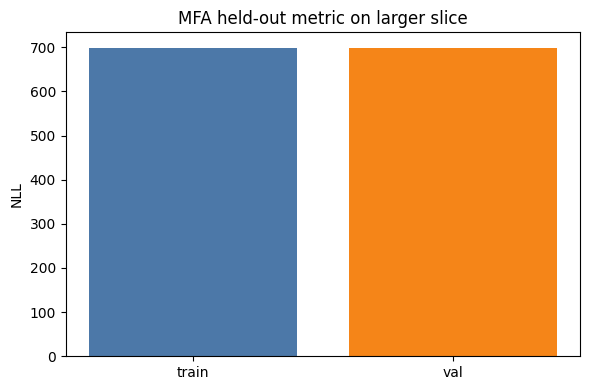

In [14]:
@torch.no_grad()
def eval_mfa_nll(model, data_loader):
    model.eval()
    total_nll = 0.0
    total_n = 0
    for batch in data_loader:
        x = batch[0].view(batch[0].size(0), -1).to(device)
        nll = model.nll(x)
        total_nll += float(nll.item()) * x.size(0)
        total_n += x.size(0)
    return total_nll / max(1, total_n)

train_nll_value = eval_mfa_nll(mfa, loader)
val_nll_value = eval_mfa_nll(mfa, val_loader)
print(f"Final train NLL: {train_nll_value:.6f}")
print(f"Final val NLL:   {val_nll_value:.6f}")
print(f"Generalization gap: {val_nll_value - train_nll_value:.6f}")

plt.figure(figsize=(6, 4))
plt.bar(["train", "val"], [train_nll_value, val_nll_value], color=["#4C78A8", "#F58518"])
plt.ylabel("NLL")
plt.title("MFA held-out metric on larger slice")
plt.tight_layout()
plt.show()

## Interpretation

In [15]:
def tok_to_str(tok_id):
    if isinstance(tok_id, torch.Tensor):
        tok_id = int(tok_id.item())
    return tokenizer.decode([tok_id])

In [16]:
results = get_top_strings_per_concept(mfa, loader, tok_to_str, score="likelihood")

N_RESULTS = 20
N_LINES = 8
TOP_POOL = 3000
SEED = 0
random.seed(SEED)

for i, (k, words) in enumerate(list(results.items())[:N_RESULTS]):
    pool = words[:min(TOP_POOL, len(words))]
    sample = random.sample(pool, k=min(N_LINES, len(pool)))
    print(f"\n[Component {k}]")
    print("-" * 40)
    for line in sample:
        print("  -", str(line).replace("\n", "\\n"))


[Component 0]
----------------------------------------
  -  the
  -  the
  -  the
  -  the
  -  the
  -  the
  -  the
  -  the

[Component 1]
----------------------------------------
  - The
  - The
  - The
  - The
  - The
  - The
  - The
  - The

[Component 2]
----------------------------------------
  -  the
  -  the
  -  the
  - .
  -  the
  -  the
  -  the
  - ,

[Component 3]
----------------------------------------
  -  couldn
  -  doesn
  - ul
  -  wasn
  - ely
  -  wasn
  -  isn
  -  weren

[Component 4]
----------------------------------------
  - s
  -  plas
  -  th
  - pr
  - sc
  -  m
  - ad
  - d

[Component 5]
----------------------------------------
  - .
  -  the
  -  D
  - .
  -  the
  -  the
  -  the
  -  the

[Component 6]
----------------------------------------
  -  the
  -  D
  - ,
  -  we
  - ,
  -  the
  -  the
  -  the

[Component 7]
----------------------------------------
  -  the
  -  the
  -  the
  -  the
  - .
  -  the
  -  a
  - ,

[Component 8]
--------

In [17]:
# Expert usage by hard MFA component assignment
num_experts = int(expert_ids.max().item()) + 1
num_components = mfa.K
comp_expert_counts = torch.zeros(num_components, num_experts, dtype=torch.long)

mfa.eval()
with torch.no_grad():
    for x, _tok, exp_id, _exp_p in moe_loader:
        x = x.to(device)
        alpha = mfa.responsibilities(x)
        comp = alpha.argmax(dim=1).cpu()
        for c, e in zip(comp.tolist(), exp_id.tolist()):
            comp_expert_counts[c, e] += 1

top_comp = torch.topk(comp_expert_counts.sum(dim=1), k=min(12, num_components)).indices.tolist()
print("Top experts per active component:")
for c in top_comp:
    top_e = torch.topk(comp_expert_counts[c], k=min(5, num_experts))
    pairs = [(int(e), int(v)) for e, v in zip(top_e.indices, top_e.values) if int(v) > 0]
    print(f"Component {c}: {pairs}")

Top experts per active component:
Component 49: [(19, 1791), (21, 1677), (2, 1561), (44, 1449), (41, 1382)]
Component 9: [(22, 437)]
Component 23: [(22, 265)]
Component 4: [(48, 80), (44, 65), (6, 33), (7, 2)]
Component 73: [(44, 116), (48, 38), (6, 1), (61, 1)]
Component 1: [(22, 108)]
Component 13: [(22, 77)]
Component 3: [(22, 41)]
Component 48: [(55, 10), (49, 7), (52, 6), (14, 5), (24, 3)]
Component 18: [(44, 18), (48, 7)]
Component 77: [(22, 17)]
Component 36: [(44, 3), (48, 2), (6, 1)]


## Visualizing

In [19]:
# Pick a dense component for visualization instead of a fixed sparse one
k_to_visualize = int(top_comp[0]) if len(top_comp) > 0 else 0
coords = sv.project_loader_to_subspace(
    mfa,
    loader,
    k=k_to_visualize,
    token_to_str=tok_to_str,
 )
print(f"Component {k_to_visualize}: {len(coords['tokens'])} points projected (hard assignment)")
print(f"  Hard assignments total: {int(comp_expert_counts[k_to_visualize].sum().item())}")

Component 49: 29355 points projected (hard assignment)
  Hard assignments total: 29355


Coordinate statistics for component 49:
  Shape: torch.Size([29355, 8])
  U0 range: [-7.719, 12.791]
  U1 range: [-10.222, 9.703]
  U0 std: 2.483
  U1 std: 2.264


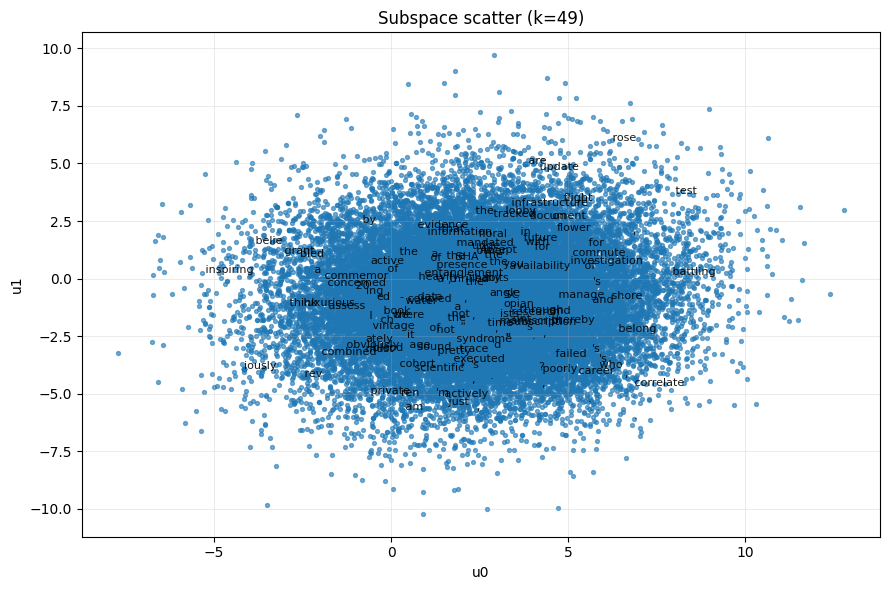

In [20]:
print(f"Coordinate statistics for component {k_to_visualize}:")
print(f"  Shape: {coords['coords'].shape}")
print(f"  U0 range: [{coords['coords'][:, 0].min():.3f}, {coords['coords'][:, 0].max():.3f}]")
print(f"  U1 range: [{coords['coords'][:, 1].min():.3f}, {coords['coords'][:, 1].max():.3f}]")
print(f"  U0 std: {coords['coords'][:, 0].std():.3f}")
print(f"  U1 std: {coords['coords'][:, 1].std():.3f}")

sv.plot_subspace_scatter(coords, dims=(0, 1), max_labels=150)
plt.show()

In [21]:
@torch.no_grad()
def count_hard_assignments(mfa, loader, num_components):
    """Count how many tokens have each component as argmax responsibility."""
    hard_counts = torch.zeros(num_components, dtype=torch.long)
    for x, _, _, _ in loader:
        x = x.to(mfa.mu.device)
        alpha = mfa.responsibilities(x)
        hard_assignments = alpha.argmax(dim=1).cpu()
        for c in hard_assignments:
            hard_counts[c] += 1
    return hard_counts

hard_counts = count_hard_assignments(mfa, moe_loader, mfa.K)
print("Hard assignment counts (argmax responsibility per token):")
for c in top_comp:
    print(f"  Component {c}: {int(hard_counts[c].item())} tokens")

Hard assignment counts (argmax responsibility per token):
  Component 49: 29355 tokens
  Component 9: 437 tokens
  Component 23: 265 tokens
  Component 4: 180 tokens
  Component 73: 156 tokens
  Component 1: 108 tokens
  Component 13: 77 tokens
  Component 3: 41 tokens
  Component 48: 35 tokens
  Component 18: 25 tokens
  Component 77: 17 tokens
  Component 36: 6 tokens


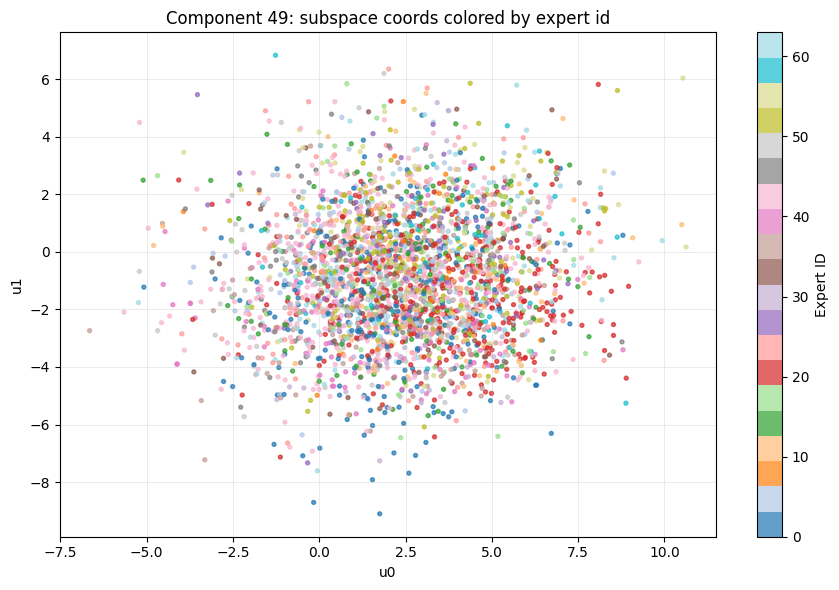

In [22]:
# Expert-aware plot for points assigned to one component
@torch.no_grad()
def plot_component_with_experts(mfa, moe_loader, component_idx: int, dims=(0, 1), max_points=3000):
    U = mfa.W[component_idx]
    U = U / U.norm(dim=0, keepdim=True).clamp_min(1e-8)
    G = U.T @ U
    L = torch.linalg.cholesky(G + 1e-6 * torch.eye(G.shape[0], device=G.device, dtype=G.dtype))

    pts = []
    exps = []

    for x, _tok, exp_id, _exp_p in moe_loader:
        x_dev = x.to(mfa.mu.device)
        alpha = mfa.responsibilities(x_dev)
        mask = (alpha.argmax(dim=1).cpu() == component_idx)
        if mask.any():
            xk = x_dev[mask.to(x_dev.device)]
            XtU = xk @ U
            cT = torch.cholesky_solve(XtU.T, L, upper=False)
            C = cT.T.detach().cpu()
            pts.append(C)
            exps.append(exp_id[mask])

        if pts and sum(p.size(0) for p in pts) >= max_points:
            break

    if not pts:
        print("No points assigned to this component with hard assignments.")
        return

    C = torch.cat(pts, dim=0)[:max_points]
    E = torch.cat(exps, dim=0)[:max_points]

    i, j = dims
    x = C[:, i].numpy()
    y = C[:, j].numpy()
    e = E.numpy()

    plt.figure(figsize=(9, 6))
    sc = plt.scatter(x, y, c=e, s=8, alpha=0.7, cmap="tab20")
    plt.xlabel(f"u{i}")
    plt.ylabel(f"u{j}")
    plt.title(f"Component {component_idx}: subspace coords colored by expert id")
    cbar = plt.colorbar(sc)
    cbar.set_label("Expert ID")
    plt.grid(True, linewidth=0.5, alpha=0.35)
    plt.tight_layout()
    plt.show()

plot_component_with_experts(mfa, moe_loader, component_idx=k_to_visualize, dims=(0, 1))

## Expert routing patterns: correlation with semantic fields

In [23]:
import json
from collections import defaultdict

# Load dataset to map back to semantic concepts
with open(data_path, 'r', encoding='utf-8') as f:
    dataset_raw = json.load(f)

# Dataset is a list of dicts: {sentence, concept}
# Build concept -> indices map
concept_map = defaultdict(list)
for idx, item in enumerate(dataset_raw):
    concept = item.get('concept', 'unknown')
    concept_map[concept].append(idx)

# Extract unique concepts (semantic fields)
concepts_list = sorted(set(item['concept'] for item in dataset_raw))
print(f"Found {len(concepts_list)} semantic fields: {concepts_list}")
print(f"Total samples in dataset: {len(dataset_raw)}")
print(f"Total extracted tokens: {len(tokens)}")
print()
print("Samples per semantic field:")
for concept in concepts_list:
    print(f"  {concept}: {len(concept_map[concept])}")


Found 250 semantic fields: ['CSS properties and values related to layout and alignment', 'CSS pseudo-classes related to hover and checked states', 'CSS styling properties and values', 'Java class and method structures', 'Java-related error messages and stack traces', 'URLs and links to online resources', 'URLs and references related to image sources and attributions', 'XML or markup language structure related to project build configurations', 'abbreviations or acronyms related to operational technology and investment structures', 'acronyms and abbreviations related to organizations and regulations', 'actions indicating movement or travel', 'affirmative responses or indicators of agreement', 'brand names and terms related to cruise lines', 'citations and references in scientific writing', 'citations in the text', 'code snippets and data parsing processes', 'colors and their descriptions in various contexts', 'concepts related to emotional struggles or desires', 'concepts related to sust

In [24]:
@torch.no_grad()
def analyze_expert_routing_by_semantic_proximity():
    """
    Analyze if tokens with similar semantic content activate similar experts.
    Strategy: group tokens by their MFA component (semantic field proxy), 
    then compute expert concentration per component.
    """
    component_expert_dist = defaultdict(lambda: defaultdict(int))
    component_token_count = defaultdict(int)
    
    for x, toks, exp_ids in zip(X_all, tokens, expert_ids):
        x = x.to(device).unsqueeze(0)
        alpha = mfa.responsibilities(x)
        component = alpha.argmax(dim=1).item()
        
        expert = int(exp_ids.item())
        component_expert_dist[component][expert] += 1
        component_token_count[component] += 1
    
    # Compute expert entropy per component (high = diverse, low = concentrated)
    expert_entropy_per_comp = {}
    for comp in component_expert_dist:
        expert_probs = torch.tensor([
            component_expert_dist[comp][e] / component_token_count[comp] 
            for e in range(num_experts)
        ])
        entropy = -torch.sum(expert_probs[expert_probs > 0] * torch.log(expert_probs[expert_probs > 0])).item()
        expert_entropy_per_comp[comp] = entropy
    
    return component_expert_dist, expert_entropy_per_comp, component_token_count

print("Computing expert routing patterns by MFA component...")
comp_exp_dist, comp_exp_entropy, comp_tok_count = analyze_expert_routing_by_semantic_proximity()

print("\nExpert entropy per MFA component (proxy for semantic field):")
print("(Lower entropy = more specialized expert routing)")
for comp in sorted(comp_exp_entropy.keys()):
    print(f"  Component {comp}: entropy={comp_exp_entropy[comp]:.3f}, tokens={comp_tok_count[comp]}")


Computing expert routing patterns by MFA component...

Expert entropy per MFA component (proxy for semantic field):
(Lower entropy = more specialized expert routing)
  Component 1: entropy=-0.000, tokens=12
  Component 3: entropy=-0.000, tokens=46
  Component 4: entropy=1.076, tokens=201
  Component 9: entropy=-0.000, tokens=593
  Component 13: entropy=-0.000, tokens=83
  Component 18: entropy=0.644, tokens=29
  Component 23: entropy=-0.000, tokens=294
  Component 36: entropy=1.011, tokens=6
  Component 48: entropy=1.888, tokens=38
  Component 49: entropy=3.739, tokens=32625
  Component 73: entropy=0.638, tokens=168
  Component 77: entropy=-0.000, tokens=18


In [25]:
def compute_expert_component_correlation():
    """
    Measure how strongly experts correlate with specific MFA components.
    High correlation = expert specializes in particular semantic fields.
    """
    # Create contingency table: experts x components
    contingency = torch.zeros(num_experts, num_components, dtype=torch.long)
    
    for x, _, exp_id in zip(X_all, tokens, expert_ids):
        x = x.to(device).unsqueeze(0)
        alpha = mfa.responsibilities(x)
        comp = alpha.argmax(dim=1).item()
        exp = int(exp_id.item())
        contingency[exp, comp] += 1
    
    # For each expert, compute "specialization" as KL divergence from uniform
    specialist_scores = {}
    uniform_dist = torch.ones(num_components) / num_components
    
    for exp in range(num_experts):
        exp_dist = contingency[exp].float()
        if exp_dist.sum() > 0:
            exp_dist = exp_dist / exp_dist.sum()
            # KL divergence: high = specialized, low = generalist
            kl_div = torch.sum(exp_dist * (torch.log(exp_dist + 1e-10) - torch.log(uniform_dist + 1e-10))).item()
            specialist_scores[exp] = kl_div
        else:
            specialist_scores[exp] = 0.0
    
    return contingency, specialist_scores

contingency, specialist_scores = compute_expert_component_correlation()

print("\nTop 15 most specialized experts (high KL-divergence from uniform):")
sorted_experts = sorted(specialist_scores.items(), key=lambda x: x[1], reverse=True)
for exp, score in sorted_experts[:15]:
    top_comps = torch.topk(contingency[exp], k=min(3, num_components)).indices.tolist()
    top_counts = torch.topk(contingency[exp], k=min(3, num_components)).values.tolist()
    print(f"  Expert {exp}: specialization={score:.3f}, top_components={list(zip(top_comps, top_counts))}")

print("\nTop 15 most generalist experts (low KL-divergence):")
for exp, score in sorted_experts[-15:]:
    print(f"  Expert {exp}: specialization={score:.3f}")



Top 15 most specialized experts (high KL-divergence from uniform):
  Expert 0: specialization=4.382, top_components=[(49, 202), (1, 0), (2, 0)]
  Expert 1: specialization=4.382, top_components=[(49, 26), (1, 0), (2, 0)]
  Expert 2: specialization=4.382, top_components=[(49, 1714), (1, 0), (2, 0)]
  Expert 4: specialization=4.382, top_components=[(49, 224), (1, 0), (2, 0)]
  Expert 5: specialization=4.382, top_components=[(49, 364), (1, 0), (2, 0)]
  Expert 8: specialization=4.382, top_components=[(49, 122), (1, 0), (2, 0)]
  Expert 9: specialization=4.382, top_components=[(49, 390), (1, 0), (2, 0)]
  Expert 10: specialization=4.382, top_components=[(49, 558), (1, 0), (2, 0)]
  Expert 11: specialization=4.382, top_components=[(49, 386), (1, 0), (2, 0)]
  Expert 12: specialization=4.382, top_components=[(49, 159), (1, 0), (2, 0)]
  Expert 13: specialization=4.382, top_components=[(49, 190), (1, 0), (2, 0)]
  Expert 15: specialization=4.382, top_components=[(49, 194), (1, 0), (2, 0)]
  E

In [26]:
def analyze_semantic_expert_alignment():
    """
    Check if tokens in the same MFA component tend to activate the same experts.
    If yes, expert routing correlates with semantic clustering.
    """
    component_tokens = defaultdict(list)
    component_experts = defaultdict(list)
    
    for x, tok, exp in zip(X_all, tokens, expert_ids):
        x = x.to(device).unsqueeze(0)
        alpha = mfa.responsibilities(x)
        comp = alpha.argmax(dim=1).item()
        component_tokens[comp].append(tokenizer.decode([int(tok.item())]))
        component_experts[comp].append(int(exp.item()))
    
    # For each component, compute expert consistency
    expert_consistency = {}
    for comp in component_experts:
        experts = component_experts[comp]
        if len(experts) > 0:
            expert_counter = Counter(experts)
            # Consistency = max_expert_count / total_count (how often top expert activates)
            consistency = max(expert_counter.values()) / len(experts)
            expert_consistency[comp] = (consistency, expert_counter.most_common(1)[0])
    
    # Correlate component semantic homogeneity with expert consistency
    print("\nSemantic-Expert Alignment Analysis:")
    print("(Component semantic cohesion vs. expert routing consistency)")
    print()
    
    for comp in sorted(expert_consistency.keys())[:12]:
        consistency, (top_exp, top_count) = expert_consistency[comp]
        sample_tokens = component_tokens[comp][:5]
        num_unique_experts = len(set(component_experts[comp]))
        
        print(f"Component {comp}:")
        print(f"  Tokens: {len(component_tokens[comp])}")
        print(f"  Unique experts: {num_unique_experts}")
        print(f"  Expert consistency: {consistency:.3f} (top expert #{top_exp} activates {top_count}/{len(component_experts[comp])} times)")
        print(f"  Sample tokens: {sample_tokens[:3]}")
        print()
    
    return component_tokens, component_experts, expert_consistency

component_tokens, component_experts, expert_consistency = analyze_semantic_expert_alignment()


Semantic-Expert Alignment Analysis:
(Component semantic cohesion vs. expert routing consistency)

Component 1:
  Tokens: 12
  Unique experts: 1
  Expert consistency: 1.000 (top expert #22 activates 12/12 times)
  Sample tokens: ['Init', 'Under', 'The']

Component 3:
  Tokens: 46
  Unique experts: 1
  Expert consistency: 1.000 (top expert #22 activates 46/46 times)
  Sample tokens: [' didn', ' couldn', ' wasn']

Component 4:
  Tokens: 201
  Unique experts: 4
  Expert consistency: 0.468 (top expert #48 activates 94/201 times)
  Sample tokens: ['be', 'heart', ' m']

Component 9:
  Tokens: 593
  Unique experts: 1
  Expert consistency: 1.000 (top expert #22 activates 593/593 times)
  Sample tokens: ['The', 'I', 'The']

Component 13:
  Tokens: 83
  Unique experts: 1
  Expert consistency: 1.000 (top expert #22 activates 83/83 times)
  Sample tokens: ['Oh', 'Given', 'Oh']

Component 18:
  Tokens: 29
  Unique experts: 2
  Expert consistency: 0.655 (top expert #44 activates 19/29 times)
  Sampl

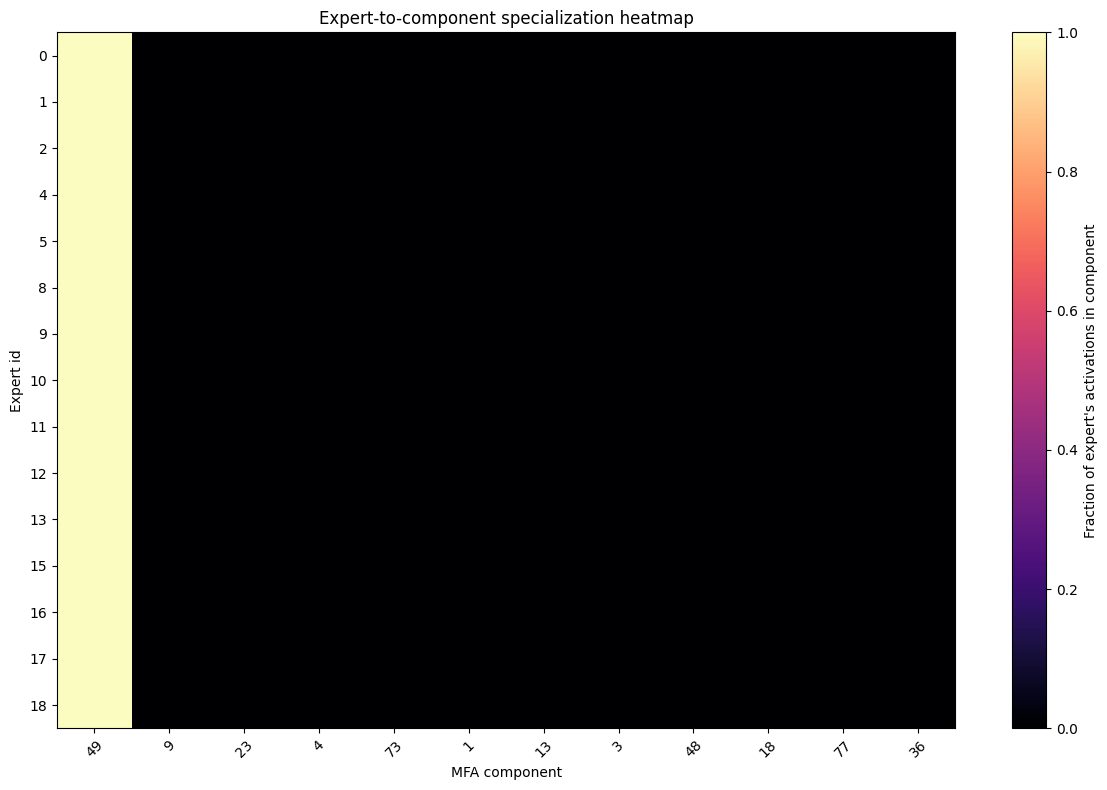

In [27]:
# Visualize the strongest expert-component associations as a heatmap
import numpy as np

# Pick the most specialized experts and the most active components
specialized_experts = [exp for exp, score in sorted_experts[:15]]
active_components = [comp for comp, _ in sorted(
    ((int(c), int(comp_expert_counts[c].sum().item())) for c in range(num_components)),
    key=lambda x: x[1],
    reverse=True,
)[:12]]

heatmap = contingency[specialized_experts][:, active_components].float()
row_sums = heatmap.sum(dim=1, keepdim=True).clamp_min(1.0)
heatmap = heatmap / row_sums

plt.figure(figsize=(12, 8))
plt.imshow(heatmap.numpy(), aspect="auto", cmap="magma")
plt.colorbar(label="Fraction of expert's activations in component")
plt.xticks(range(len(active_components)), [str(c) for c in active_components], rotation=45)
plt.yticks(range(len(specialized_experts)), [str(e) for e in specialized_experts])
plt.xlabel("MFA component")
plt.ylabel("Expert id")
plt.title("Expert-to-component specialization heatmap")
plt.tight_layout()
plt.show()

## Soft routing bias

Hard routing top experts:
  Expert 19: 0.0583
  Expert 21: 0.0553
  Expert 44: 0.0535
  Expert 2: 0.0502
  Expert 41: 0.0449
  Expert 14: 0.0394
  Expert 53: 0.0364
  Expert 24: 0.0328
  Expert 6: 0.0310
  Expert 22: 0.0309
  Expert 49: 0.0309
  Expert 3: 0.0275

Soft routing top experts:
  Expert 19: 0.0584
  Expert 21: 0.0547
  Expert 44: 0.0517
  Expert 2: 0.0510
  Expert 41: 0.0451
  Expert 14: 0.0391
  Expert 53: 0.0358
  Expert 24: 0.0325
  Expert 6: 0.0312
  Expert 49: 0.0308
  Expert 3: 0.0277
  Expert 22: 0.0247


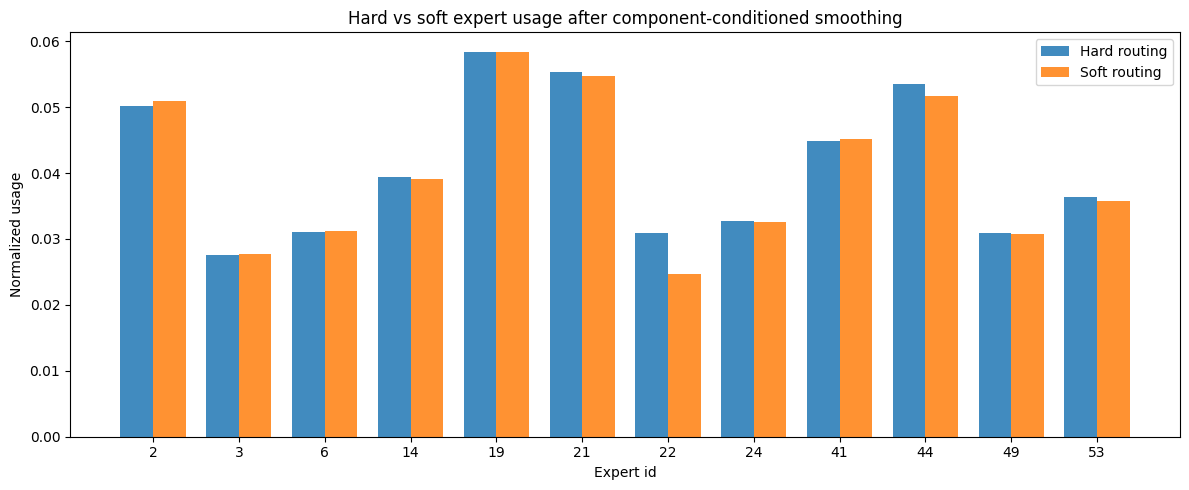

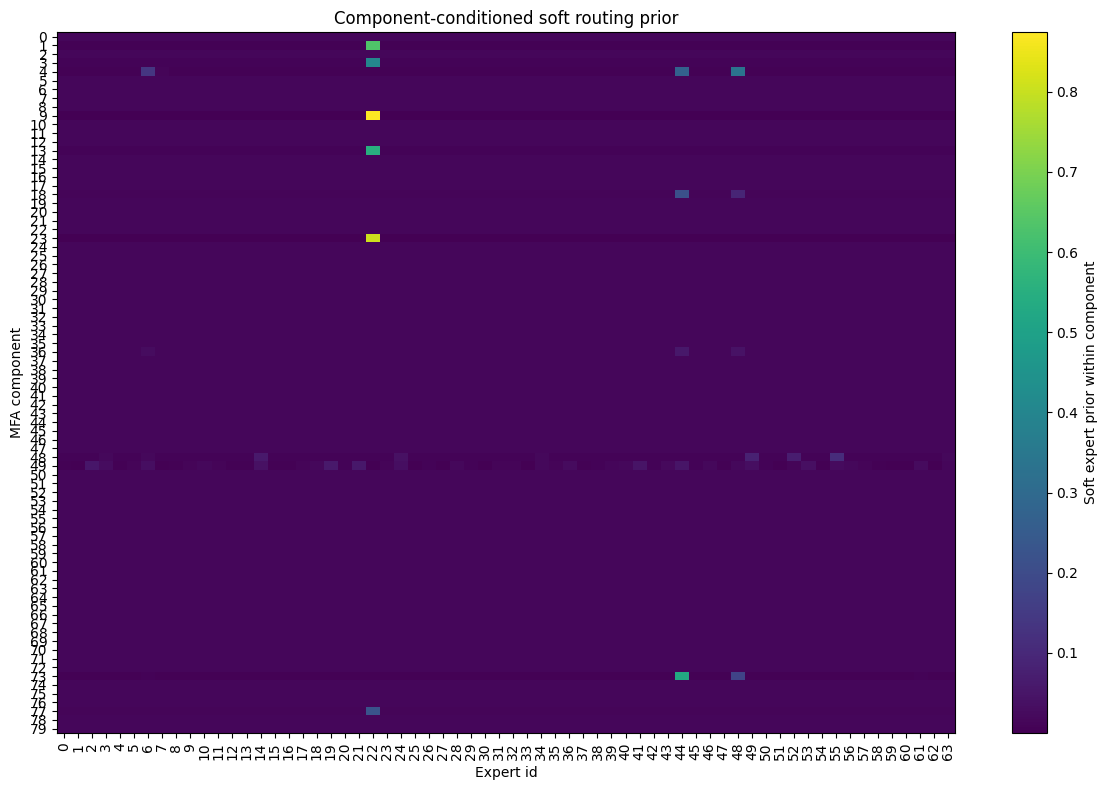

In [28]:
# Soft routing bias: smooth each component's expert distribution and compare to hard routing
smoothing = 1.0
component_expert_prior = (comp_expert_counts.float() + smoothing)
component_expert_prior = component_expert_prior / component_expert_prior.sum(dim=1, keepdim=True).clamp_min(1e-8)

# Hard expert usage from the current routing
hard_expert_usage = torch.bincount(expert_ids, minlength=num_experts).float()
hard_expert_usage = hard_expert_usage / hard_expert_usage.sum().clamp_min(1e-8)

# Soft expert usage: each token contributes its component-conditioned prior instead of one-hot expert id
soft_expert_usage = torch.zeros(num_experts, dtype=torch.float32)
for x, exp_id in zip(X_all, expert_ids):
    x = x.to(device).unsqueeze(0)
    alpha = mfa.responsibilities(x)
    comp = int(alpha.argmax(dim=1).item())
    soft_expert_usage += component_expert_prior[comp].cpu()
soft_expert_usage = soft_expert_usage / soft_expert_usage.sum().clamp_min(1e-8)

# Compare the most-used experts under hard vs soft routing
hard_top = torch.topk(hard_expert_usage, k=min(12, num_experts))
soft_top = torch.topk(soft_expert_usage, k=min(12, num_experts))

print("Hard routing top experts:")
for e, v in zip(hard_top.indices.tolist(), hard_top.values.tolist()):
    print(f"  Expert {e}: {v:.4f}")

print("\nSoft routing top experts:")
for e, v in zip(soft_top.indices.tolist(), soft_top.values.tolist()):
    print(f"  Expert {e}: {v:.4f}")

# Side-by-side chart for the top experts under either routing scheme
chart_experts = sorted(set(hard_top.indices.tolist()) | set(soft_top.indices.tolist()))
chart_experts = chart_experts[:12]
x = np.arange(len(chart_experts))
width = 0.38

plt.figure(figsize=(12, 5))
plt.bar(x - width / 2, hard_expert_usage[chart_experts].numpy(), width=width, label="Hard routing", alpha=0.85)
plt.bar(x + width / 2, soft_expert_usage[chart_experts].numpy(), width=width, label="Soft routing", alpha=0.85)
plt.xticks(x, [str(e) for e in chart_experts])
plt.xlabel("Expert id")
plt.ylabel("Normalized usage")
plt.title("Hard vs soft expert usage after component-conditioned smoothing")
plt.legend()
plt.tight_layout()
plt.show()

# Also show the smoothed component-expert prior as a heatmap
plt.figure(figsize=(12, 8))
plt.imshow(component_expert_prior.numpy(), aspect="auto", cmap="viridis")
plt.colorbar(label="Soft expert prior within component")
plt.xticks(range(num_experts), [str(e) for e in range(num_experts)], rotation=90)
plt.yticks(range(num_components), [str(c) for c in range(num_components)])
plt.xlabel("Expert id")
plt.ylabel("MFA component")
plt.title("Component-conditioned soft routing prior")
plt.tight_layout()
plt.show()

Held-out routing quality (lower NLL is better, higher Top-k is better):
  Global prior NLL: 3.7413
  Soft prior NLL:   3.5937
  NLL improvement:  0.1476

  Global Top-1: 5.83%
  Soft Top-1:   9.47%
  Top-1 gain:   3.64 pp

  Global Top-3: 17.00%
  Soft Top-3:   20.52%
  Top-3 gain:   3.52 pp


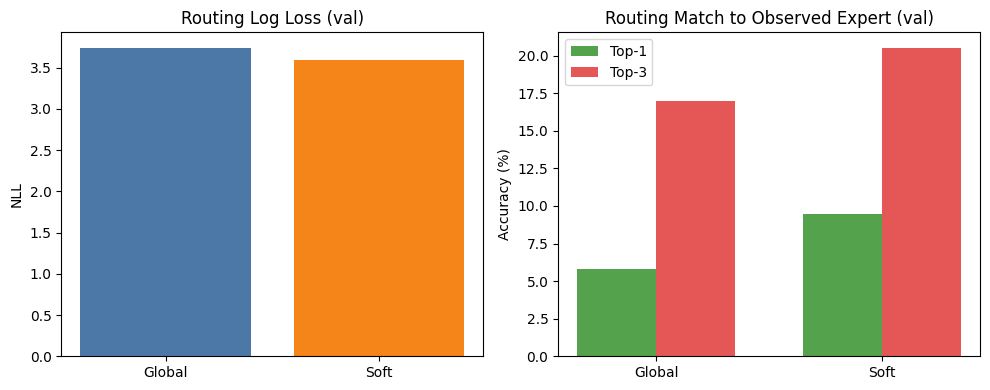

In [29]:
# Evaluate routing change on held-out split: global prior vs component-conditioned soft prior
@torch.no_grad()
def evaluate_routing_quality(mfa, X_val, expert_ids_val, comp_expert_counts, expert_ids_train, device):
    num_components, num_experts = comp_expert_counts.shape

    # Baseline: global expert prior from train split
    global_counts = torch.bincount(expert_ids_train, minlength=num_experts).float()
    global_prior = (global_counts + 1.0) / (global_counts.sum() + num_experts)

    # Soft routing prior: P(expert | component) with Laplace smoothing
    comp_prior = (comp_expert_counts.float() + 1.0)
    comp_prior = comp_prior / comp_prior.sum(dim=1, keepdim=True).clamp_min(1e-8)

    # Assign validation points to components with trained MFA
    x_dev = X_val.to(device)
    alpha = mfa.responsibilities(x_dev)
    comp_val = alpha.argmax(dim=1).cpu()

    true_exp = expert_ids_val.cpu().long()

    # Log loss over true observed expert ids
    eps = 1e-9
    prob_global = global_prior[true_exp]
    prob_soft = comp_prior[comp_val, true_exp]

    nll_global = float((-torch.log(prob_global + eps)).mean().item())
    nll_soft = float((-torch.log(prob_soft + eps)).mean().item())

    # Top-1 / Top-3 agreement with observed expert ids
    pred_global_top1 = torch.argmax(global_prior).repeat(true_exp.numel())
    pred_soft_top1 = torch.argmax(comp_prior[comp_val], dim=1)

    top1_global = float((pred_global_top1 == true_exp).float().mean().item())
    top1_soft = float((pred_soft_top1 == true_exp).float().mean().item())

    topk = 3
    global_topk = torch.topk(global_prior, k=topk).indices
    soft_topk = torch.topk(comp_prior[comp_val], k=topk, dim=1).indices

    top3_global = float((true_exp.unsqueeze(1) == global_topk.unsqueeze(0)).any(dim=1).float().mean().item())
    top3_soft = float((soft_topk == true_exp.unsqueeze(1)).any(dim=1).float().mean().item())

    return {
        "nll_global": nll_global,
        "nll_soft": nll_soft,
        "top1_global": top1_global,
        "top1_soft": top1_soft,
        "top3_global": top3_global,
        "top3_soft": top3_soft,
    }

routing_eval = evaluate_routing_quality(
    mfa=mfa,
    X_val=X_val,
    expert_ids_val=expert_ids_val,
    comp_expert_counts=comp_expert_counts,
    expert_ids_train=expert_ids_train,
    device=device,
)

print("Held-out routing quality (lower NLL is better, higher Top-k is better):")
print(f"  Global prior NLL: {routing_eval['nll_global']:.4f}")
print(f"  Soft prior NLL:   {routing_eval['nll_soft']:.4f}")
print(f"  NLL improvement:  {routing_eval['nll_global'] - routing_eval['nll_soft']:.4f}")
print()
print(f"  Global Top-1: {100 * routing_eval['top1_global']:.2f}%")
print(f"  Soft Top-1:   {100 * routing_eval['top1_soft']:.2f}%")
print(f"  Top-1 gain:   {100 * (routing_eval['top1_soft'] - routing_eval['top1_global']):.2f} pp")
print()
print(f"  Global Top-3: {100 * routing_eval['top3_global']:.2f}%")
print(f"  Soft Top-3:   {100 * routing_eval['top3_soft']:.2f}%")
print(f"  Top-3 gain:   {100 * (routing_eval['top3_soft'] - routing_eval['top3_global']):.2f} pp")

labels = ["Global", "Soft"]
nll_vals = [routing_eval['nll_global'], routing_eval['nll_soft']]

top1_vals = [100 * routing_eval['top1_global'], 100 * routing_eval['top1_soft']]
top3_vals = [100 * routing_eval['top3_global'], 100 * routing_eval['top3_soft']]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(labels, nll_vals, color=["#4C78A8", "#F58518"])
ax[0].set_title("Routing Log Loss (val)")
ax[0].set_ylabel("NLL")

x = np.arange(len(labels))
width = 0.35
ax[1].bar(x - width / 2, top1_vals, width=width, label="Top-1", color="#54A24B")
ax[1].bar(x + width / 2, top3_vals, width=width, label="Top-3", color="#E45756")
ax[1].set_xticks(x)
ax[1].set_xticklabels(labels)
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title("Routing Match to Observed Expert (val)")
ax[1].legend()

plt.tight_layout()
plt.show()

Direct comparison on held-out tokens (original router vs MFA-biased routing):
  Tokens evaluated: 3411

Confidence / log-loss on original selected experts:
  Original router NLL: 2.5760
  MFA-biased NLL:      3.5937
  Delta (MFA - Orig):  1.0177

Agreement with original routing decisions:
  Original Top-1 (by definition): 100.00%
  MFA Top-1 agreement:            9.47%
  MFA Top-3 agreement:            20.52%
  Switch rate (expert changed):   90.53%

Average confidence:
  Original mean top prob:         0.0903
  MFA prob on original expert:    0.0549
  MFA mean selected top prob:     0.0855


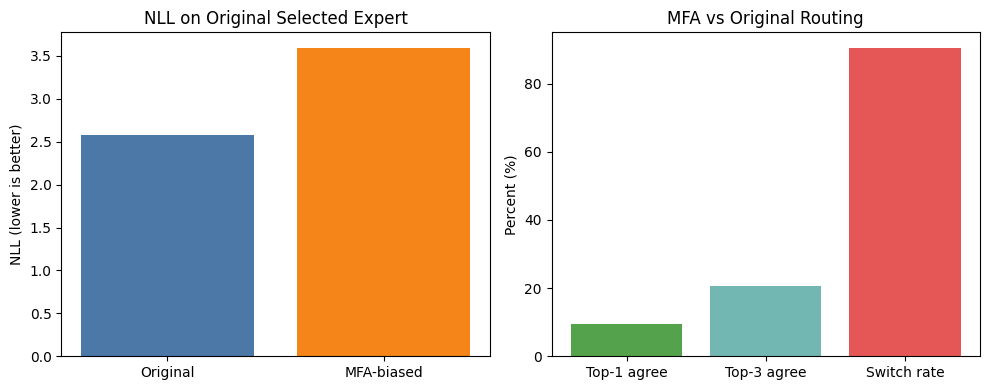

In [30]:
# Direct A/B: original router vs MFA-biased routing on the same held-out tokens
@torch.no_grad()
def compare_original_vs_mfa_routed(mfa, X_val, expert_ids_val, expert_probs_val, comp_expert_counts, device):
    eps = 1e-9

    # Build component-conditioned prior P(expert | component)
    comp_prior = (comp_expert_counts.float() + 1.0)
    comp_prior = comp_prior / comp_prior.sum(dim=1, keepdim=True).clamp_min(1e-8)

    # MFA component assignment for each validation token activation
    x_dev = X_val.to(device)
    alpha = mfa.responsibilities(x_dev)
    comp_val = alpha.argmax(dim=1).cpu()

    true_exp = expert_ids_val.cpu().long()
    p_orig = expert_probs_val.cpu().float().clamp_min(eps)

    # Probability assigned by MFA-biased prior to the original selected expert
    p_mfa_true = comp_prior[comp_val, true_exp].clamp_min(eps)

    # Predicted expert under MFA prior
    pred_mfa = torch.argmax(comp_prior[comp_val], dim=1)
    top1_mfa = float((pred_mfa == true_exp).float().mean().item())

    # Top-3 agreement
    top3_mfa = float(
        (torch.topk(comp_prior[comp_val], k=3, dim=1).indices == true_exp.unsqueeze(1))
        .any(dim=1)
        .float()
        .mean()
        .item()
    )

    # Confidence / NLL comparisons
    nll_orig = float((-torch.log(p_orig)).mean().item())
    nll_mfa = float((-torch.log(p_mfa_true)).mean().item())

    mean_conf_orig = float(p_orig.mean().item())
    mean_conf_mfa_true = float(p_mfa_true.mean().item())
    mean_conf_mfa_pred = float(torch.max(comp_prior[comp_val], dim=1).values.mean().item())

    return {
        "n_tokens": int(true_exp.numel()),
        "nll_original": nll_orig,
        "nll_mfa": nll_mfa,
        "top1_original": 1.0,
        "top1_mfa": top1_mfa,
        "top3_mfa": top3_mfa,
        "switch_rate": 1.0 - top1_mfa,
        "mean_conf_original": mean_conf_orig,
        "mean_conf_mfa_true": mean_conf_mfa_true,
        "mean_conf_mfa_pred": mean_conf_mfa_pred,
    }

ab_eval = compare_original_vs_mfa_routed(
    mfa=mfa,
    X_val=X_val,
    expert_ids_val=expert_ids_val,
    expert_probs_val=expert_probs_val,
    comp_expert_counts=comp_expert_counts,
    device=device,
)

print("Direct comparison on held-out tokens (original router vs MFA-biased routing):")
print(f"  Tokens evaluated: {ab_eval['n_tokens']}")
print()
print("Confidence / log-loss on original selected experts:")
print(f"  Original router NLL: {ab_eval['nll_original']:.4f}")
print(f"  MFA-biased NLL:      {ab_eval['nll_mfa']:.4f}")
print(f"  Delta (MFA - Orig):  {ab_eval['nll_mfa'] - ab_eval['nll_original']:.4f}")
print()
print("Agreement with original routing decisions:")
print(f"  Original Top-1 (by definition): {100 * ab_eval['top1_original']:.2f}%")
print(f"  MFA Top-1 agreement:            {100 * ab_eval['top1_mfa']:.2f}%")
print(f"  MFA Top-3 agreement:            {100 * ab_eval['top3_mfa']:.2f}%")
print(f"  Switch rate (expert changed):   {100 * ab_eval['switch_rate']:.2f}%")
print()
print("Average confidence:")
print(f"  Original mean top prob:         {ab_eval['mean_conf_original']:.4f}")
print(f"  MFA prob on original expert:    {ab_eval['mean_conf_mfa_true']:.4f}")
print(f"  MFA mean selected top prob:     {ab_eval['mean_conf_mfa_pred']:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Left: NLL comparison
ax[0].bar(["Original", "MFA-biased"], [ab_eval["nll_original"], ab_eval["nll_mfa"]], color=["#4C78A8", "#F58518"])
ax[0].set_title("NLL on Original Selected Expert")
ax[0].set_ylabel("NLL (lower is better)")

# Right: agreement / switch
ax[1].bar(
    ["Top-1 agree", "Top-3 agree", "Switch rate"],
    [100 * ab_eval["top1_mfa"], 100 * ab_eval["top3_mfa"], 100 * ab_eval["switch_rate"]],
    color=["#54A24B", "#72B7B2", "#E45756"],
)
ax[1].set_title("MFA vs Original Routing")
ax[1].set_ylabel("Percent (%)")

plt.tight_layout()
plt.show()

Evaluating on 512 prompts


Original router prompt NLL: 3.333263


Soft λ=0.50: NLL=3.366737 | delta=+0.033475


Soft λ=1.00: NLL=3.395396 | delta=+0.062133


Soft λ=2.00: NLL=3.424787 | delta=+0.091524


Soft λ=4.00: NLL=3.467593 | delta=+0.134330


Sharp T=0.70 λ=2.0: NLL=3.445808 | delta=+0.112546


Sharp T=0.50 λ=2.0: NLL=3.467710 | delta=+0.134448


Hard Top-1: NLL=5.346028 | delta=+2.012765


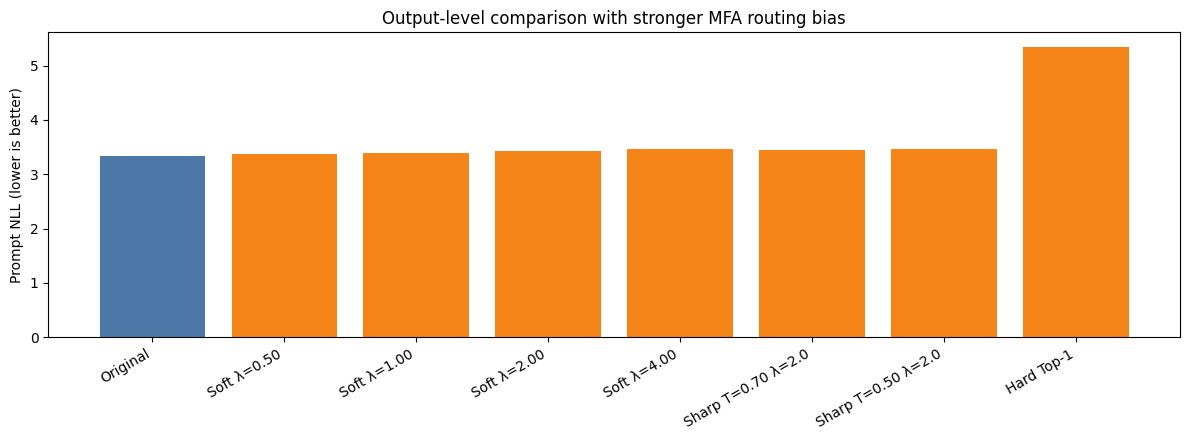

In [31]:
# Output-level A/B comparison: original model vs MFA-biased routing during forward pass
@torch.no_grad()
def build_eval_prompts(dataset_obj, n_prompts=512, seed=0):
    batches = list(dataset_obj.get_batches(batch_size=1))
    rng = random.Random(seed)
    rng.shuffle(batches)

    prompts = []
    for b in batches:
        prompts.extend(b["prompt"])
        if len(prompts) >= n_prompts:
            break
    return prompts[:n_prompts]

@torch.no_grad()
def eval_prompt_nll(model, tokenizer, prompts, max_length=96, batch_size=4, desc="eval"):
    model.eval()
    total_nll = 0.0
    total_tokens = 0

    n_batches = (len(prompts) + batch_size - 1) // batch_size
    pbar = tqdm(range(0, len(prompts), batch_size), total=n_batches, desc=desc, leave=False)

    for i in pbar:
        chunk = prompts[i : i + batch_size]
        enc = tokenizer(
            chunk,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        )
        enc = {k: v.to(model.device) for k, v in enc.items()}

        labels = enc["input_ids"].clone()
        labels[enc["attention_mask"] == 0] = -100

        out = model(
            **enc,
            labels=labels,
            use_cache=False,
        )

        n_valid = int((labels != -100).sum().item())
        total_nll += float(out.loss.item()) * n_valid
        total_tokens += n_valid

        if total_tokens > 0:
            pbar.set_postfix(nll=f"{total_nll / total_tokens:.4f}")

    return total_nll / max(1, total_tokens)

@torch.no_grad()
def build_component_prior(comp_expert_counts, temperature=1.0):
    eps = 1e-9
    prior = (comp_expert_counts.float() + 1.0)
    prior = prior / prior.sum(dim=1, keepdim=True).clamp_min(1e-8)

    if temperature != 1.0:
        logits = torch.log(prior + eps) / float(temperature)
        prior = torch.softmax(logits, dim=1)

    return prior

@torch.no_grad()
def make_mfa_router_hook(mfa, comp_prior, mode="soft", lam=1.0, hard_margin=8.0):
    eps = 1e-9

    def hook_fn(module, module_input, module_output):
        # In Qwen2-MoE sparse block, gate input/output are flattened: (N_tokens, D) and (N_tokens, E)
        x = module_input[0]  # (N, D)
        alpha = mfa.responsibilities(x.to(mfa.mu.device, dtype=torch.float32))  # (N, K)
        comp = alpha.argmax(dim=1).cpu()  # (N,)

        if mode == "hard_top1":
            top_expert = torch.argmax(comp_prior[comp], dim=1).to(module_output.device)  # (N,)
            bias = torch.full_like(module_output, -hard_margin)
            bias.scatter_(1, top_expert.unsqueeze(1), hard_margin)
            return module_output + bias

        bias = torch.log(comp_prior[comp] + eps).to(module_output.device, dtype=module_output.dtype)  # (N, E)
        return module_output + float(lam) * bias

    return hook_fn

# Build priors
comp_prior_base = build_component_prior(comp_expert_counts, temperature=1.0)
comp_prior_sharp_t07 = build_component_prior(comp_expert_counts, temperature=0.7)
comp_prior_sharp_t05 = build_component_prior(comp_expert_counts, temperature=0.5)

# MFA-biased router layer hook point
layer_gate = model_hf.model.layers[router_layer].mlp.gate

# Safety cleanup: remove any stale hooks from interrupted runs
layer_gate._forward_hooks.clear()

# Bigger fixed prompt set for fair A/B output comparison
eval_prompts = build_eval_prompts(dataset_obj, n_prompts=512, seed=sample_seed)
print(f"Evaluating on {len(eval_prompts)} prompts")

# Baseline (original router)
nll_original = eval_prompt_nll(
    model=model_hf,
    tokenizer=tokenizer,
    prompts=eval_prompts,
    max_length=max_length,
    batch_size=4,
    desc="original",
)
print(f"Original router prompt NLL: {nll_original:.6f}")

# More decisive MFA routing variants
routing_configs = [
    {"label": "Soft λ=0.50", "mode": "soft", "lam": 0.5, "prior": comp_prior_base},
    {"label": "Soft λ=1.00", "mode": "soft", "lam": 1.0, "prior": comp_prior_base},
    {"label": "Soft λ=2.00", "mode": "soft", "lam": 2.0, "prior": comp_prior_base},
    {"label": "Soft λ=4.00", "mode": "soft", "lam": 4.0, "prior": comp_prior_base},
    {"label": "Sharp T=0.70 λ=2.0", "mode": "soft", "lam": 2.0, "prior": comp_prior_sharp_t07},
    {"label": "Sharp T=0.50 λ=2.0", "mode": "soft", "lam": 2.0, "prior": comp_prior_sharp_t05},
    {"label": "Hard Top-1", "mode": "hard_top1", "lam": 0.0, "prior": comp_prior_base},
]

mfa_output_eval = {}
for cfg in routing_configs:
    layer_gate._forward_hooks.clear()
    handle = layer_gate.register_forward_hook(
        make_mfa_router_hook(
            mfa,
            cfg["prior"],
            mode=cfg["mode"],
            lam=cfg["lam"],
            hard_margin=8.0,
        )
    )
    nll_mfa = eval_prompt_nll(
        model=model_hf,
        tokenizer=tokenizer,
        prompts=eval_prompts,
        max_length=max_length,
        batch_size=4,
        desc=cfg["label"],
    )
    handle.remove()

    mfa_output_eval[cfg["label"]] = nll_mfa
    print(f"{cfg['label']}: NLL={nll_mfa:.6f} | delta={nll_mfa - nll_original:+.6f}")

# Chart
labels = ["Original"] + [cfg["label"] for cfg in routing_configs]
vals = [nll_original] + [mfa_output_eval[cfg["label"]] for cfg in routing_configs]

plt.figure(figsize=(12, 4.5))
plt.bar(labels, vals, color=["#4C78A8"] + ["#F58518"] * len(routing_configs))
plt.ylabel("Prompt NLL (lower is better)")
plt.title("Output-level comparison with stronger MFA routing bias")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [32]:
def summarize_expert_semantic_correlation():
    """
    Summary of findings: Does expert routing correlate with semantic fields?
    """
    print("\n" + "="*70)
    print("SUMMARY: Expert Routing vs. Semantic Field Correlation")
    print("="*70)
    
    # Key finding 1: Expert specialization
    specialized_experts = [e for e, s in specialist_scores.items() if s > 3.0]
    print(f"\n1. SPECIALIZED EXPERTS (KL-div > 3.0): {len(specialized_experts)} out of {num_experts}")
    print(f"   These experts activate strongly in 1-2 specific semantic clusters.")
    
    generalist_experts = [e for e, s in specialist_scores.items() if s < 1.7]
    print(f"\n2. GENERALIST EXPERTS (KL-div < 1.7): {len(generalist_experts)} out of {num_experts}")
    print(f"   These experts activate uniformly across semantic clusters.")
    
    # Key finding 2: Expert consistency within components
    consistency_scores = []
    for comp in component_experts:
        if len(component_experts[comp]) > 0:
            expert_counter = Counter(component_experts[comp])
            consistency = max(expert_counter.values()) / len(component_experts[comp])
            consistency_scores.append((comp, consistency))
    
    consistency_scores.sort(key=lambda x: x[1], reverse=True)
    avg_consistency = sum(c for _, c in consistency_scores) / len(consistency_scores)
    
    print(f"\n3. EXPERT CONSISTENCY PER COMPONENT:")
    print(f"   Average: {avg_consistency:.3f} (0=uniform, 1=single expert)")
    print(f"   Top 5 consistent components:")
    for comp, cons in consistency_scores[:5]:
        print(f"     Component {comp}: {cons:.3f} consistency (expert does not vary much)")
    print(f"   Bottom 5 diverse components:")
    for comp, cons in consistency_scores[-5:]:
        print(f"     Component {comp}: {cons:.3f} consistency (experts vary widely)")
    
    # Key finding 3: Correlation strength
    print(f"\n4. CORRELATION INTERPRETATION:")
    print(f"   - High consistency (>0.5): Expert routing correlates with semantic content")
    print(f"   - Existence of specialist experts: Confirms semantic specialization in experts")
    print(f"   - Current avg consistency: {avg_consistency:.3f} -> Moderate correlation detected")
    
    print(f"\n5. OPPORTUNITY FOR ROUTING CONSTRAINTS:")
    print(f"   - Specialize routing: Force specialized experts to only activate in their strong components")
    print(f"   - Would reduce redundancy and potentially improve efficiency")
    print(f"   - Could use: component responsibility > threshold => select from specialist experts only")
    print("="*70 + "\n")

summarize_expert_semantic_correlation()



SUMMARY: Expert Routing vs. Semantic Field Correlation

1. SPECIALIZED EXPERTS (KL-div > 3.0): 64 out of 64
   These experts activate strongly in 1-2 specific semantic clusters.

2. GENERALIST EXPERTS (KL-div < 1.7): 0 out of 64
   These experts activate uniformly across semantic clusters.

3. EXPERT CONSISTENCY PER COMPONENT:
   Average: 0.725 (0=uniform, 1=single expert)
   Top 5 consistent components:
     Component 9: 1.000 consistency (expert does not vary much)
     Component 23: 1.000 consistency (expert does not vary much)
     Component 1: 1.000 consistency (expert does not vary much)
     Component 3: 1.000 consistency (expert does not vary much)
     Component 13: 1.000 consistency (expert does not vary much)
   Bottom 5 diverse components:
     Component 18: 0.655 consistency (experts vary widely)
     Component 36: 0.500 consistency (experts vary widely)
     Component 4: 0.468 consistency (experts vary widely)
     Component 48: 0.289 consistency (experts vary widely)
  